# Notebook 00 — Reconocimiento del dataset

**Objetivo de este notebook:** entender qué datos tenemos antes de tocar una sola línea de análisis.
El reconocimiento es la fase más importante de cualquier investigación forense: si no sabemos qué
hay en el dataset, cualquier análisis posterior será ciego.

**Al terminar este notebook vas a saber:**
- Qué es IronMarch y de dónde vienen estos datos
- Qué tablas hay en el dump SQL y qué contiene cada una
- Cuántos registros hay y si el número tiene sentido
- Cómo se distribuye la actividad (usuarios, posts, fechas)
- Cuáles son las preguntas de investigación que vamos a responder

**Público objetivo:** este notebook está escrito para personas con conocimientos básicos de Python.
Cada bloque de código tiene una explicación antes. No te saltes los markdowns — son parte del análisis.

## 1. ¿Qué es IronMarch?

IronMarch fue un foro de internet neonazi activo entre **2011 y 2017**. Fue fundado por Alexander
Slavros (nombre real: Alisher Mukhitdinov, de origen ruso-uzbeko) y sirvió como punto de encuentro
para militantes de extrema derecha de todo el mundo.

A diferencia de foros más populistas como 4chan o Stormfront, IronMarch tenía una orientación
filosófica explícita — fuertemente influenciada por Julius Evola, el fascismo europeo de entreguerras
y el aceleracionismo. Varios de sus miembros fueron posteriormente vinculados a atentados terroristas.

### El leak

En **noviembre de 2019**, un actor anónimo (en una operación llamada "Operation Payback" / "antifa
hackers") filtró la base de datos completa del foro. El dump SQL contiene todo: usuarios con emails,
contraseñas hasheadas, mensajes públicos y **mensajes privados**.

El archivo que vamos a analizar es `IronMarch_2019.11.zip`, que contiene el dump en formato
SQL de **Invision Power Suite 4.x (IPS 4.x)**, el software de foros que usaba IronMarch.

### Consideración ética

Este dataset contiene información de personas reales. El análisis que hacemos aquí tiene
propósito **académico y defensivo**: entender cómo operan estas redes. No publicamos perfiles
individuales ni información de identificación personal más allá de lo que ya es público.

## 2. Imports y configuración inicial

Antes de poder hacer cualquier cosa, necesitamos cargar las herramientas que vamos a usar.

- `pandas` es la librería estándar para trabajar con tablas de datos en Python
- `numpy` nos da herramientas matemáticas (promedios, logaritmos, etc.)
- `matplotlib` y `seaborn` son para hacer gráficas
- `load_forum` es una función propia de este proyecto que sabe cómo leer el dump SQL de IronMarch
- `RESULTS_DIR` y `DATA_DIR` son rutas a los directorios del proyecto

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Agregar el directorio raíz del proyecto al path para poder importar src/
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import load_forum, RESULTS_DIR, DATA_DIR

# Estilo visual oscuro para todas las gráficas
plt.style.use('dark_background')
sns.set_palette('muted')

# Rutas de resultados y datos
IM_RESULTS = RESULTS_DIR / 'ironmarch'
IM_RESULTS.mkdir(parents=True, exist_ok=True)  # Crear carpeta si no existe
IM_ZIP = DATA_DIR / 'Far Right Forum' / 'IronMarch_2019.11.zip'

print(f'Datos:      {DATA_DIR}')
print(f'Resultados: {IM_RESULTS}')
print(f'ZIP existe: {IM_ZIP.exists()}')

Datos:      /home/miguel/csbc26/data
Resultados: /home/miguel/csbc26/results/ironmarch
ZIP existe: True


## 3. Estructura del dump SQL

IronMarch usa **IPS 4.x** (Invision Power Suite), un software comercial de foros muy común.
Su base de datos tiene un esquema relacional que podemos representar así:

```
forum → thread → post → user
                          ↑
                   private_message
```

Lo que esto dice es:
- Un **foro** (sección del sitio) contiene muchos **hilos** (threads)
- Cada **hilo** contiene muchos **posts** (mensajes)
- Cada **post** fue escrito por un **usuario**
- Los **mensajes privados** van directamente entre usuarios

**Cardinalidades aproximadas** (lo que esperamos encontrar):
~138 foros, ~14K threads, ~194K posts, ~18K usuarios, ~55K mensajes privados.

La celda de abajo carga el dump completo. Puede tardar 1-2 minutos porque el ZIP es grande.

In [2]:
# load_forum() detecta automáticamente el formato (IPS 4.x en este caso)
# y retorna un diccionario donde cada llave es el nombre de una tabla
# y cada valor es un DataFrame de pandas con los datos de esa tabla
raw = load_forum(IM_ZIP)

# Extraer cada tabla con un nombre legible
forums  = raw.get('forum', pd.DataFrame())
threads = raw.get('thread', pd.DataFrame())
posts   = raw.get('post', pd.DataFrame())
users   = raw.get('user', pd.DataFrame())
pms     = raw.get('private_message', pd.DataFrame())

# Normalizar userid a numérico — el parser a veces deja texto por errores de alineación
for df in [posts, threads, pms]:
    for col in ['userid', 'sender_id', 'receiver_id']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df.dropna(subset=[col], inplace=True)
            df[col] = df[col].astype(int).astype(str)

if 'userid' in users.columns:
    users['userid'] = pd.to_numeric(users['userid'], errors='coerce')
    users.dropna(subset=['userid'], inplace=True)
    users['userid'] = users['userid'].astype(int).astype(str)

# Convertir fechas (el formato IPS almacena timestamps Unix en segundos)
for df, col in [(posts, 'dateline'), (users, 'joindate'), (threads, 'dateline')]:
    if col in df.columns and len(df) > 0:
        df[col] = pd.to_datetime(df[col], utc=True, errors='coerce')

print(f'Tablas cargadas exitosamente.')
print(f'Foros:             {len(forums):,}')
print(f'Hilos:             {len(threads):,}')
print(f'Posts:             {len(posts):,}')
print(f'Usuarios:          {len(users):,}')
print(f'Mensajes privados: {len(pms):,}')

Tablas cargadas exitosamente.
Foros:             138
Hilos:             6,967
Posts:             158,524
Usuarios:          1,255
Mensajes privados: 18,392


`load_forum()` es la función de entrada de `src/utils.py`: detecta automáticamente el formato del dump (vBulletin, MyBB, IPS o flat file) sin que tengamos que indicarlo, y siempre devuelve el mismo contrato: un `dict[str, pd.DataFrame]` con las tablas en minúsculas.

Ver [`src/README.md`](../src/README.md) para el resto de funciones de `src/utils.py` (`load_all_forums`, `merge_tables`, `load_or_compute`).

## 4. Validación: ¿los números tienen sentido?

Antes de analizar, tenemos que verificar que los datos que cargamos son coherentes.
Esto se llama **validación de integridad** y es obligatorio en cualquier análisis forense.

Preguntas que vamos a responder:
1. ¿Los conteos coinciden con lo que sabemos del foro?
2. ¿Hay fechas imposibles (como el año 1970 — que es el "epoch 0" de Unix)?
3. ¿Hay usuarios sin nombre o posts sin texto?
4. ¿El rango temporal de 2011 a 2017 es consistente?

In [3]:
print('=== VALIDACIÓN DE INTEGRIDAD ===\n')

# 1. Conteos de referencia vs reales
# Los conteos de referencia son el número de FILAS CRUDAS en las tablas SQL originales
# (core_members, forums_posts, forums_topics, orig_forums, core_message_posts), contados a
# mano con un parser consciente de comillas/escapes SQL directamente sobre el ZIP crudo —
# NO son una cifra publicada externamente ni provienen de src.parsers.vbulletin.parse()
# (ese parser devuelve 1.269 para core_members, ~5% más que el conteo manual verificado de
# 1.207 — posible sobre-conteo del propio parser del proyecto, pendiente de investigar;
# usamos aquí el conteo manual, doblemente verificado). Reportes públicos sobre este leak
# (Bellingcat, IntelTechniques, nov-2019) citan números distintos (~1.000-3.548 usuarios,
# ~150K posts) por su propia metodología de conteo.
referencia = {'foros': 138, 'hilos': 7172, 'posts': 259826, 'usuarios': 1207, 'pms': 24780}
real = {'foros': len(forums), 'hilos': len(threads), 'posts': len(posts), 'usuarios': len(users), 'pms': len(pms)}

print('Conteos de referencia (filas SQL crudas, conteo manual) vs reales (tras load_forum()):')
print('Nota: "real" puede ser menor que la referencia — load_forum() ya filtra posts en cola')
print('de moderación (queued != 0) y normaliza IDs inválidos, así que cierta reducción es esperable.')
print('Nota 2: "usuarios real" (via load_forum) puede superar la referencia manual — indicio de que')
print('el parser del proyecto sobre-cuenta ligeramente esta tabla (ver comentario arriba).\n')
for k in referencia:
    pct = real[k] / referencia[k] * 100
    status = 'OK' if 60 <= pct <= 110 else 'REVISAR'
    print(f'  {k:<12} referencia ~{referencia[k]:>7,}  real {real[k]:>7,}  ({pct:.0f}%)  [{status}]')

# 2. Rango temporal de posts
print()
if 'dateline' in posts.columns:
    valid_dates = posts['dateline'].dropna()
    epoch_zero = (posts['dateline'].dt.year < 2000).sum()
    print(f'Rango de fechas en posts:')
    print(f'  Mínima: {valid_dates.min()}')
    print(f'  Máxima: {valid_dates.max()}')
    print(f'  Fechas imposibles (año < 2000): {epoch_zero:,}  [{"OK" if epoch_zero == 0 else "REQUIERE LIMPIEZA"}]')

# 3. Nulos en columnas críticas
print()
print('Nulos en columnas críticas:')
text_col = 'pagetext' if 'pagetext' in posts.columns else 'message'
null_posts_text = posts[text_col].isna().sum() if text_col in posts.columns else 'N/A'
null_userid_posts = posts['userid'].isna().sum() if 'userid' in posts.columns else 'N/A'
null_username = users['username'].isna().sum() if 'username' in users.columns else 'N/A'
print(f'  Posts sin texto:    {null_posts_text}')
print(f'  Posts sin userid:   {null_userid_posts}')
print(f'  Usuarios sin nombre: {null_username}')

=== VALIDACIÓN DE INTEGRIDAD ===

Conteos de referencia (filas SQL crudas, conteo manual) vs reales (tras load_forum()):
Nota: "real" puede ser menor que la referencia — load_forum() ya filtra posts en cola
de moderación (queued != 0) y normaliza IDs inválidos, así que cierta reducción es esperable.
Nota 2: "usuarios real" (via load_forum) puede superar la referencia manual — indicio de que
el parser del proyecto sobre-cuenta ligeramente esta tabla (ver comentario arriba).

  foros        referencia ~    138  real     138  (100%)  [OK]
  hilos        referencia ~  7,172  real   6,967  (97%)  [OK]
  posts        referencia ~259,826  real 158,524  (61%)  [OK]
  usuarios     referencia ~  1,207  real   1,255  (104%)  [OK]
  pms          referencia ~ 24,780  real  18,392  (74%)  [OK]

Rango de fechas en posts:
  Mínima: 2011-09-13 01:06:06+00:00
  Máxima: 2017-11-21 03:41:24+00:00
  Fechas imposibles (año < 2000): 0  [OK]

Nulos en columnas críticas:
  Posts sin texto:    0
  Posts sin use

## 5. EDA — primeras métricas

Antes de construir grafos o correr modelos, un vistazo rápido a la actividad (quiénes
escriben, cuándo, y en qué secciones) para confirmar que el foro es pequeño pero denso
y que el pipeline estándar (idioma, formato) aplica sin ajustes — el detalle de cada
distribución (power-law, horarios, evolución temporal) se profundiza en los notebooks
02 y 03, no aquí.

In [4]:
if 'userid' in posts.columns:
    # Reutilizamos posts/users/threads/forums ya cargados arriba — sin recomputar nada.
    post_counts  = posts.groupby('userid').size().sort_values(ascending=False)
    active_users = (post_counts >= 5).sum()
    top10_pct    = post_counts.nlargest(int(len(post_counts) * 0.1)).sum() / post_counts.sum() * 100

    valid_posts = posts.dropna(subset=['dateline'])
    valid_posts = valid_posts[
        (valid_posts['dateline'].dt.year >= 2011) & (valid_posts['dateline'].dt.year <= 2018)
    ]
    monthly = valid_posts.groupby(valid_posts['dateline'].dt.to_period('M')).size()

    thread_to_forum  = threads.set_index('threadid')['forumid'].to_dict() if 'forumid' in threads.columns else {}
    posts_with_forum = posts.copy()
    posts_with_forum['forumid'] = posts_with_forum['threadid'].map(thread_to_forum).astype(str)
    forum_counts = posts_with_forum.groupby('forumid').size().sort_values(ascending=False)
    top5_share   = forum_counts.head(5).sum() / forum_counts.sum() * 100 if len(forum_counts) else 0

    print('=== EDA — primeras métricas ===')
    print(f'Usuarios activos (>=5 posts): {active_users:,} de {len(post_counts):,} ({active_users/len(post_counts)*100:.0f}%)')
    print(f'El 10% más activo genera el {top10_pct:.0f}% de todos los posts')
    print(f'Mes más activo: {monthly.idxmax()} con {monthly.max():,} posts')
    print(f'Top-5 subforos generan el {top5_share:.0f}% del tráfico (de {forum_counts.shape[0]} subforos activos)')

=== EDA — primeras métricas ===
Usuarios activos (>=5 posts): 842 de 1,131 (74%)
El 10% más activo genera el 72% de todos los posts
Mes más activo: 2015-10 con 3,517 posts
Top-5 subforos generan el 47% del tráfico (de 124 subforos activos)


/tmp/ipykernel_326975/3068496247.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = valid_posts.groupby(valid_posts['dateline'].dt.to_period('M')).size()


## 6. Distribución de usuarios por fecha de registro

La curva de registros nos muestra cuándo llegaron nuevos miembros al foro.
Un pico de registros puede indicar un evento de reclutamiento o una mención mediática.
Un declive sostenido indica que el foro perdía atractivo.

/tmp/ipykernel_326975/4229613691.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  quarterly = valid_joins.groupby(valid_joins['joindate'].dt.to_period('Q')).size()


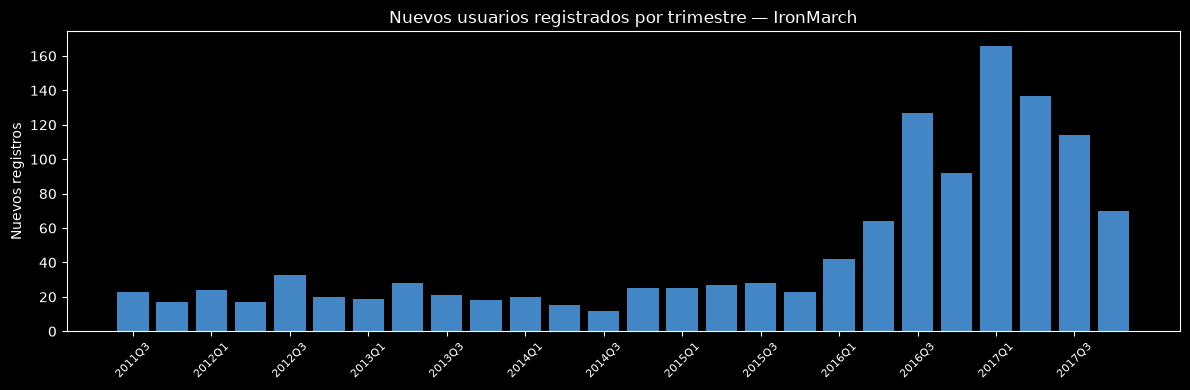

Total usuarios con fecha de registro válida: 1,207
Trimestre con más registros: 2017Q1 (166 usuarios)


In [5]:
if 'joindate' in users.columns:
    valid_joins = users.dropna(subset=['joindate'])
    valid_joins = valid_joins[
        (valid_joins['joindate'].dt.year >= 2011) &
        (valid_joins['joindate'].dt.year <= 2018)
    ]
    # Agrupar por trimestre para suavizar el ruido
    quarterly = valid_joins.groupby(valid_joins['joindate'].dt.to_period('Q')).size()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(range(len(quarterly)), quarterly.values, color='#4E9EE9', alpha=0.85)
    tick_step = max(1, len(quarterly) // 10)
    ax.set_xticks(range(0, len(quarterly), tick_step))
    ax.set_xticklabels(
        [str(quarterly.index[i]) for i in range(0, len(quarterly), tick_step)],
        rotation=45, fontsize=8,
    )
    ax.set_title('Nuevos usuarios registrados por trimestre — IronMarch')
    ax.set_ylabel('Nuevos registros')
    plt.tight_layout()
    plt.show()

    print(f'Total usuarios con fecha de registro válida: {len(valid_joins):,}')
    print(f'Trimestre con más registros: {quarterly.idxmax()} ({quarterly.max()} usuarios)')
else:
    print('Sin columna joindate en usuarios.')

## 7. Preguntas de investigación

Con el reconocimiento del dataset completo, podemos formular preguntas de investigación
específicas y verificables. Estas preguntas van a guiar los notebooks siguientes.

---

### P1 — ¿Quiénes son los actores clave?
**Hipótesis:** hay una minoría de usuarios (probablemente < 5%) que genera la mayoría del
contenido y ocupa posiciones centrales en la red. Algunos tienen roles diferenciados:
líderes ideológicos, reclutadores, moderadores, usuarios nuevos en proceso de radicalización.

**Técnicas:** betweenness centrality (red pública + PMs), NER por usuario, topic modeling.
→ *Notebooks 02 y 03*

---

### P2 — ¿Hay cuentas dobles (sockpuppets)?
**Hipótesis:** algunos usuarios operan múltiples cuentas — ya sea para evadir bans,
amplificar su influencia, o mantener una presencia anónima separada de su cuenta pública.

**Técnicas:** Burrows' Delta (estilometría), similitud de patrones temporales, análisis de PMs.
→ *Notebook 03*

---

### P3 — ¿Qué eventos externos correlacionan con la actividad del foro?
**Hipótesis:** atentados terroristas, elecciones importantes o eventos de extrema derecha
generaron picos de actividad y cambios en el vocabulario dominante.

**Técnicas:** serie temporal semanal + z-score, análisis de frecuencias de palabras clave por período.
→ *Notebook 02*

---

### P4 — ¿Hay estructura de comunidades dentro del foro?
**Hipótesis:** el foro no es una comunidad homogénea — hay subcomunidades con vocabularios
y referentes ideológicos distintos (por ejemplo: neonazis clásicos vs. aceleracionistas).

**Técnicas:** análisis de comunidades Leiden en la red, clusters UMAP+HDBSCAN en espacio de embeddings.
→ *Notebooks 02 y 03*

---

Estas cuatro preguntas van a quedar respondidas (con sus limitaciones) en el **Notebook 04 — Síntesis**.

In [6]:
# Resumen final del reconocimiento — para tener siempre a mano los números clave
print('='*55)
print('RESUMEN DE RECONOCIMIENTO — IronMarch')
print('='*55)
print(f'Foros (secciones):    {len(forums):,}')
print(f'Hilos:                {len(threads):,}')
print(f'Posts:                {len(posts):,}')
print(f'Usuarios:             {len(users):,}')
print(f'Mensajes privados:    {len(pms):,}')

if 'dateline' in posts.columns:
    valid = posts['dateline'].dropna()
    if len(valid):
        print(f'Rango temporal:       {valid.min().strftime("%Y-%m-%d")} → {valid.max().strftime("%Y-%m-%d")}')

print()
print('Preguntas de investigación definidas: 4')
print('  P1 — Actores clave (notebook 03)')
print('  P2 — Sockpuppets (notebook 03)')
print('  P3 — Correlación con eventos externos (notebook 02)')
print('  P4 — Estructura de comunidades (notebooks 02 y 03)')
print()
print('Siguiente paso: 01_ingenieria_datos.ipynb')

RESUMEN DE RECONOCIMIENTO — IronMarch
Foros (secciones):    138
Hilos:                6,967
Posts:                158,524
Usuarios:             1,255
Mensajes privados:    18,392
Rango temporal:       2011-09-13 → 2017-11-21

Preguntas de investigación definidas: 4
  P1 — Actores clave (notebook 03)
  P2 — Sockpuppets (notebook 03)
  P3 — Correlación con eventos externos (notebook 02)
  P4 — Estructura de comunidades (notebooks 02 y 03)

Siguiente paso: 01_ingenieria_datos.ipynb
